# Rendering Charts to File Formats

Render a chart to SVG, PNG, or JPG bytes using `chart.render(fmt)`.

In [28]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, Volume, Pane, LinePlot
from mplchart.indicators import SMA, RSI, MACD

from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")

In [29]:
prices = sample_prices()
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 11325 entries, 1980-12-12 to 2025-11-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    11325 non-null  float64
 1   high    11325 non-null  float64
 2   low     11325 non-null  float64
 3   close   11325 non-null  float64
 4   volume  11325 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 530.9 KB


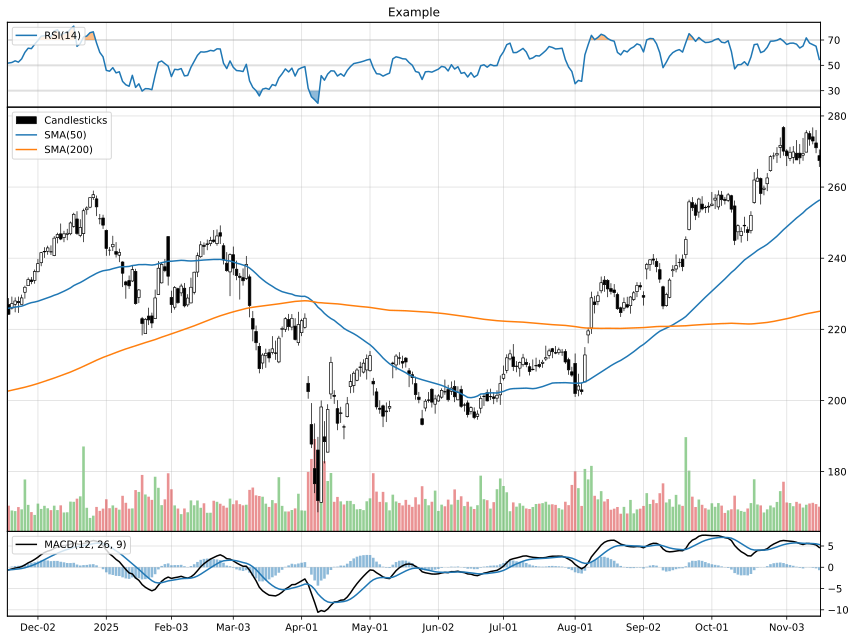

In [30]:
max_bars = 250

chart = Chart(prices, title="Example", max_bars=max_bars).plot(
    Candlesticks(use_bars=False),
    SMA(50),
    SMA(200),
    Volume(),
    Pane("above", yticks=(30, 50, 70)),
    RSI() @ LinePlot(overbought=70, oversold=30),
    Pane("below"),
    MACD(),
)

In [31]:
data = chart.render("svg")

print(data[:20] + b"...")


b'<?xml version="1.0" ...'


In [32]:
data = chart.render("png")

print(data[:20] + b"...")

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x04\xb0...'
